# Unitary Noise Analysis

This notebook analyzes how noisy the current unitary-compilation models are under quditkit global noise.

It focuses on:
- candidate circuits sampled from existing models
- clean compilation quality against the target unitary
- noisy degradation across a configurable `p` grid
- where the preferred candidate changes as noise increases


In [2]:
import os
import sys
from pathlib import Path

from IPython.display import display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from notebooks.noise_awareness.unitary_noise_analysis_helper import (
    DEFAULT_P_GRID,
    build_model_specs,
    collect_candidate_tables,
    plot_noise_overview,
    save_analysis_bundle,
    summarize_candidate_tables,
)
from notebooks.noise_awareness.unitary_noise_common import DEFAULT_RESULTS_ROOT, maybe_dataframe


In [3]:
DATASET_PATH = Path("../datasets/paper_qiskit/unitary_3q_dataset")
MODEL_DIRS = [
    Path("../models/trained/paper_unitary"),
    Path("../models/remote/qc_unitary_3qubit"),
]
TARGET_LIMIT = 16
SAMPLES_PER_TARGET = 16
P_GRID = list(DEFAULT_P_GRID)
GUIDANCE_SCALE = 4.0
AUTO_BATCH_SIZE = 64
CLEAN_INFidelity_THRESHOLD = 1e-6
NOISE_REALIZATIONS = 8
SEED = 0
DEVICE = "cuda"
OUTPUT_DIR = DEFAULT_RESULTS_ROOT / "unitary_noise_analysis_demo"

print("DATASET_PATH =", DATASET_PATH)
print("MODEL_DIRS =", MODEL_DIRS)
print("P_GRID =", P_GRID)
print("OUTPUT_DIR =", OUTPUT_DIR)


DATASET_PATH = ../datasets/paper_qiskit/unitary_3q_dataset
MODEL_DIRS = [PosixPath('../models/trained/paper_unitary'), PosixPath('../models/remote/qc_unitary_3qubit')]
P_GRID = [0.0, 0.01, 0.03, 0.1]
OUTPUT_DIR = /workspace/qcircuit-generation/notebooks/results/noise_aware_unitary/unitary_noise_analysis_demo


In [4]:
model_specs = build_model_specs(MODEL_DIRS)
analysis = collect_candidate_tables(
    DATASET_PATH,
    model_specs=model_specs,
    target_limit=TARGET_LIMIT,
    samples_per_target=SAMPLES_PER_TARGET,
    p_grid=P_GRID,
    guidance_scale=GUIDANCE_SCALE,
    auto_batch_size=AUTO_BATCH_SIZE,
    clean_infidelity_threshold=CLEAN_INFidelity_THRESHOLD,
    noise_realizations=NOISE_REALIZATIONS,
    seed=SEED,
    device=DEVICE,
)
summary = summarize_candidate_tables(analysis["candidate_rows"], analysis["score_rows"])

display(maybe_dataframe(analysis["overview"]))


[INFO]: Loading tensor from `/workspace/qcircuit-generation/datasets/paper_qiskit/unitary_3q_dataset/dataset/ds_x.safetensors` onto device: cuda.
[INFO]: Loading tensor from `/workspace/qcircuit-generation/datasets/paper_qiskit/unitary_3q_dataset/dataset/ds_y.safetensors` onto device: cuda.
[INFO]: Loading tensor from `/workspace/qcircuit-generation/datasets/paper_qiskit/unitary_3q_dataset/dataset/ds_U.safetensors` onto device: cuda.
[INFO]: Loading tensor from `/workspace/qcircuit-generation/datasets/paper_qiskit/unitary_3q_dataset/dataset/ds_z.safetensors` onto device: cuda.
[INFO]: Instantiated config_dataset from given config on cuda.
[INFO]: `genQC.models.unet_qc.QC_Compilation_UNet` instantiated from given `config` on cuda.
[INFO]: Loading model from `models/trained/paper_unitary/model.pt` onto device: cuda.
[INFO]: `genQC.models.unet_qc.QC_Compilation_UNet`. Freeze model: True
[INFO]: `my_genQC.models.frozen_open_clip.CachedFrozenOpenCLIPEmbedder` instantiated from given `config

[INFO]: `genQC.models.frozen_open_clip.CachedFrozenOpenCLIPEmbedder` instantiated from given `config` on cuda.
[INFO]: `genQC.models.frozen_open_clip.CachedFrozenOpenCLIPEmbedder`. Found no key `save_type` in `config`. No state dict loaded.
[INFO]: `genQC.models.frozen_open_clip.CachedFrozenOpenCLIPEmbedder`. Freeze model: True
[WARNING]: The value 0 is reserved for background tokens, i.e. qubit time position which are not effected by gates.
[WARNING]: Automatically incrementing all vocabulary values by one ...
[WARNING]: The value 0 is reserved for background tokens, i.e. qubit time position which are not effected by gates.
[WARNING]: Automatically incrementing all vocabulary values by one ...
[WARNING]: The value 0 is reserved for background tokens, i.e. qubit time position which are not effected by gates.
[WARNING]: Automatically incrementing all vocabulary values by one ...
[WARNING]: The value 0 is reserved for background tokens, i.e. qubit time position which are not effected by 

,dataset_path,dataset_target_count,analyzed_target_count,model_labels,samples_per_target,noise_ps,clean_infidelity_threshold,noise_realizations
0,/workspace/qcircuit-generation/datasets/paper_...,665095,16,"[paper_unitary, qc_unitary_3qubit]",16,"[0.0, 0.01, 0.03, 0.1]",0.000001,8


In [5]:
print("Target overview")
display(maybe_dataframe(analysis["target_rows"][:20]))

print("Candidate summary by model")
display(maybe_dataframe(summary["by_model"]))

print("Noise summary by p")
display(maybe_dataframe(summary["by_noise_p"]))

print("Candidate rows")
display(maybe_dataframe(analysis["candidate_rows"][:50]))

print("Noise score rows")
display(maybe_dataframe(analysis["score_rows"][:50]))


Target overview


,target_position,target_index,target_unitary_id,prompt,original_gate_count
0,0,10992,target_010992,"Compile using: ['cx', 'z', 'x', 'ccx', 'swap']",5
1,1,27250,target_027250,"Compile using: ['ccx', 'swap']",6
2,2,50041,target_050041,"Compile using: ['h', 'cx', 'z', 'x', 'ccx', 's...",9
3,3,116568,target_116568,"Compile using: ['h', 'x', 'swap']",11
4,4,179430,target_179430,"Compile using: ['h', 'z', 'x', 'ccx']",6
5,5,204732,target_204732,"Compile using: ['h', 'cx', 'x', 'ccx', 'swap']",11
6,6,334958,target_334958,"Compile using: ['h', 'cx']",12
7,7,339947,target_339947,"Compile using: ['h', 'cx', 'z', 'ccx', 'swap']",8
8,8,403469,target_403469,"Compile using: ['h', 'z', 'x', 'ccx', 'swap']",11
9,9,423631,target_423631,"Compile using: ['cx', 'z', 'x', 'swap']",11


Candidate summary by model


,dataset,paper_unitary,qc_unitary_3qubit
0,"{'valid_candidates': 6, 'mean_clean_infidelity...","{'valid_candidates': 256, 'mean_clean_infideli...","{'valid_candidates': 256, 'mean_clean_infideli..."


Noise summary by p


,0.00,0.01,0.03,0.10
0,"{'rows': 518, 'mean_noisy_score': 0.9507723038...","{'rows': 518, 'mean_noisy_score': 0.9508175500...","{'rows': 518, 'mean_noisy_score': 0.9508326449...","{'rows': 518, 'mean_noisy_score': 0.9508929860..."


Candidate rows


,candidate_id,target_position,target_index,target_unitary_id,source_model,source_rank,is_valid_decode,passes_clean_threshold,prompt,clean_frobenius,clean_infidelity,gate_count,one_qubit_gate_count,two_qubit_gate_count,depth_proxy,gate_name_histogram_json
0,0,0,10992,target_010992,dataset,0,True,False,"Compile using: ['cx', 'z', 'x', 'ccx', 'swap']",6.0,0.937500,5,2,3,4,"{""cnot"": 2, ""swap"": 1, ""z"": 2}"
1,1,0,10992,target_010992,paper_unitary,0,True,False,"Compile using: ['cx', 'z', 'x', 'ccx', 'swap']",6.0,0.937500,0,0,0,0,{}
2,2,0,10992,target_010992,paper_unitary,1,True,False,"Compile using: ['cx', 'z', 'x', 'ccx', 'swap']",6.0,0.937500,0,0,0,0,{}
3,3,0,10992,target_010992,paper_unitary,2,True,False,"Compile using: ['cx', 'z', 'x', 'ccx', 'swap']",6.0,0.937500,0,0,0,0,{}
4,4,0,10992,target_010992,paper_unitary,3,True,False,"Compile using: ['cx', 'z', 'x', 'ccx', 'swap']",6.0,0.937500,0,0,0,0,{}
5,5,0,10992,target_010992,paper_unitary,4,True,False,"Compile using: ['cx', 'z', 'x', 'ccx', 'swap']",6.0,0.937500,0,0,0,0,{}
6,6,0,10992,target_010992,paper_unitary,5,True,False,"Compile using: ['cx', 'z', 'x', 'ccx', 'swap']",6.0,0.937500,0,0,0,0,{}
7,7,0,10992,target_010992,paper_unitary,6,True,False,"Compile using: ['cx', 'z', 'x', 'ccx', 'swap']",6.0,0.937500,0,0,0,0,{}
8,8,0,10992,target_010992,paper_unitary,7,True,False,"Compile using: ['cx', 'z', 'x', 'ccx', 'swap']",6.0,0.937500,0,0,0,0,{}
9,9,0,10992,target_010992,paper_unitary,8,True,False,"Compile using: ['cx', 'z', 'x', 'ccx', 'swap']",6.0,0.937500,0,0,0,0,{}


Noise score rows


,candidate_id,target_position,target_index,target_unitary_id,source_model,noise_p,noise_proxy,noisy_score_mean,noisy_score_std,noisy_score_min,noisy_score_max
0,0,0,10992,target_010992,dataset,0.00,0.00,0.937500,0.000000,0.9375,0.9375
1,0,0,10992,target_010992,dataset,0.01,0.11,0.937500,0.000000,0.9375,0.9375
2,0,0,10992,target_010992,dataset,0.03,0.33,0.945312,0.020670,0.9375,1.0000
3,0,0,10992,target_010992,dataset,0.10,1.10,0.953125,0.027063,0.9375,1.0000
4,1,0,10992,target_010992,paper_unitary,0.00,0.00,0.937500,0.000000,0.9375,0.9375
5,1,0,10992,target_010992,paper_unitary,0.01,0.00,0.937500,0.000000,0.9375,0.9375
6,1,0,10992,target_010992,paper_unitary,0.03,0.00,0.937500,0.000000,0.9375,0.9375
7,1,0,10992,target_010992,paper_unitary,0.10,0.00,0.937500,0.000000,0.9375,0.9375
8,2,0,10992,target_010992,paper_unitary,0.00,0.00,0.937500,0.000000,0.9375,0.9375
9,2,0,10992,target_010992,paper_unitary,0.01,0.00,0.937500,0.000000,0.9375,0.9375


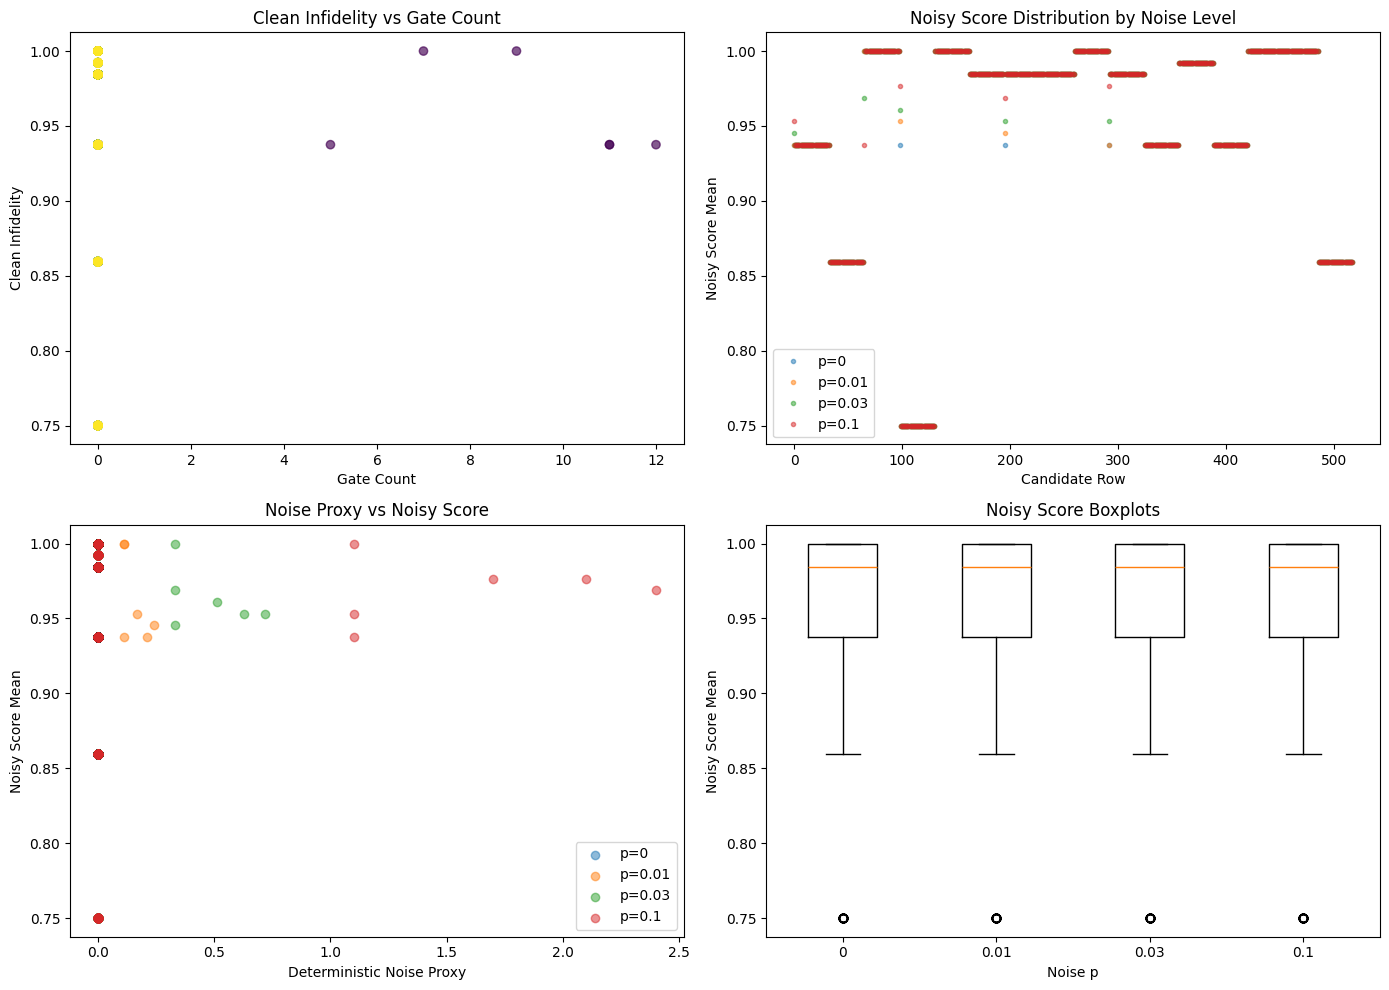

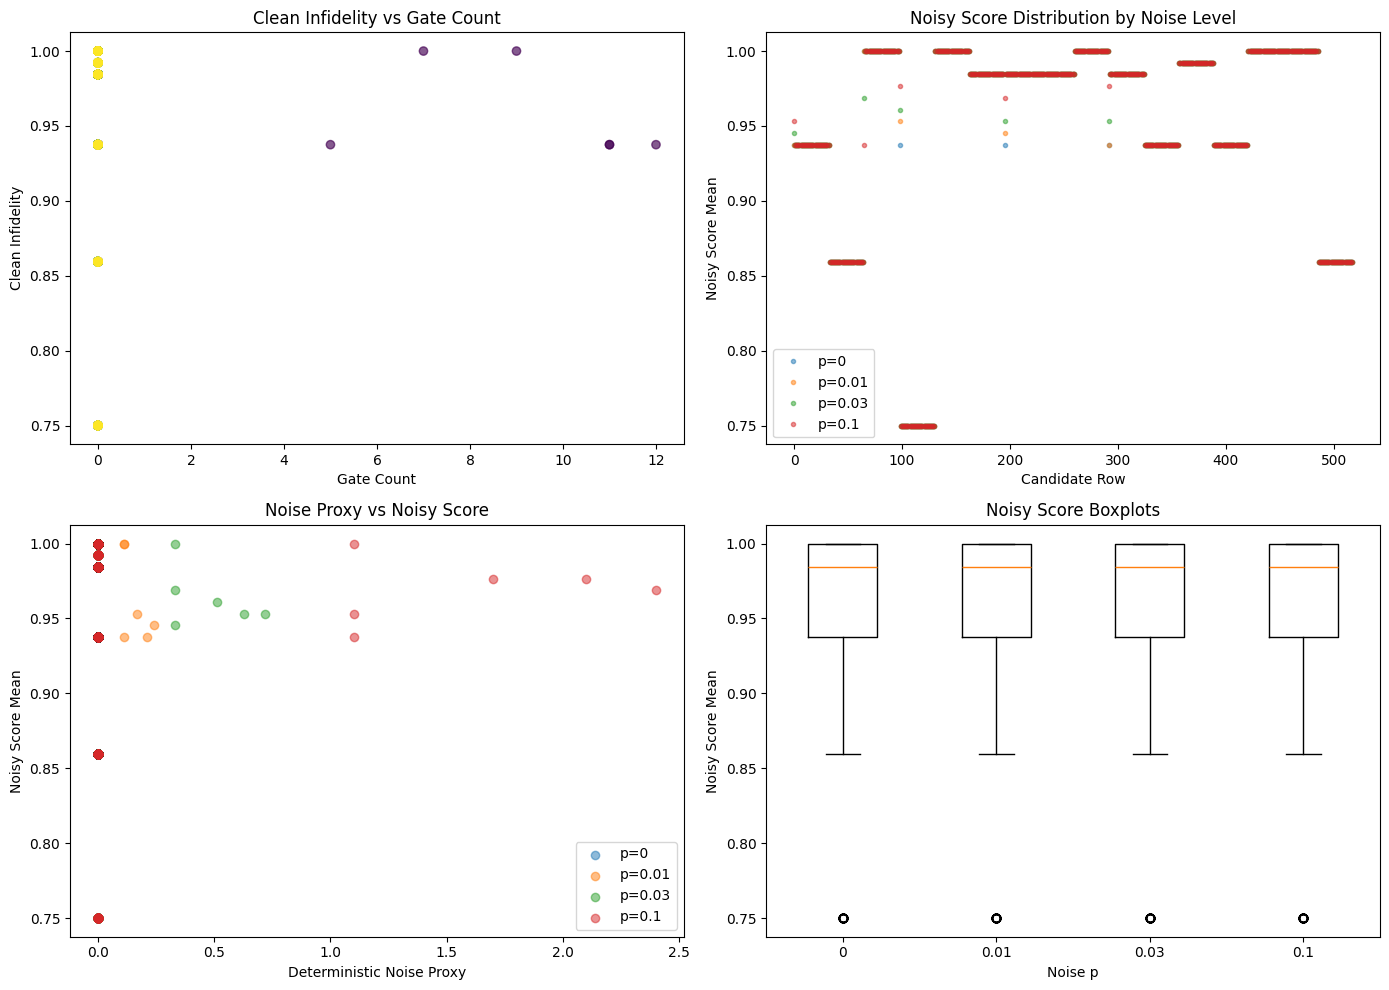

In [6]:
plot_noise_overview(analysis["candidate_rows"], analysis["score_rows"])


In [ ]:
saved_dir = save_analysis_bundle(analysis, output_dir=OUTPUT_DIR)
print("Saved analysis bundle to", saved_dir)


## Next Step

Once the candidate table looks reasonable, build a derived dataset from the terminal:

```bash
python notebooks/noise_awareness/build_unitary_noise_dataset.py \
  --source-dataset ./datasets/paper_qiskit/unitary_3q_dataset \
  --candidate-dir ./results/noise_aware_unitary/unitary_noise_analysis_demo \
  --output-dir ./datasets/noise_aware/unitary_3q_quditkit_noise_v1
```
